# Configure Preprocessing Params

This notebook should be used to set up preprocessing params.
Cells marked with <font color='red'>SET PARAMETERS</font> contain crucial variables that need to be set according to your specific experimental setup and data organization.
Please review and modify these variables as needed before proceeding with the analysis.

## Imports

In [1]:
from pathlib import Path
import yaml
import pandas as pd
from microfilm.microplot import Microimage
import matplotlib.pyplot as plt

from lib.shared.configuration_utils import (
    CONFIG_FILE_HEADER,
    create_samples_df,
    create_micropanel,
    convert_tuples_to_lists,
)
from lib.preprocess.preprocess import extract_metadata, convert_to_array
from lib.preprocess.file_utils import get_sample_fps, get_tile_count_from_well

## <font color='red'>SET PARAMETERS</font>

### Fixed parameters for preprocessing

- `CONFIG_FILE_PATH`: Path to a Brieflow config file used during processing.
- `ROOT_FP`: Path to root of Brieflow output directory.

*Note: Paths can be absolute or relative to where workflows are run from.*

In [4]:
CONFIG_FILE_PATH = "config/config.yml"
ROOT_FP = "/Volumes/Elements/brieflow_output/"

Path(CONFIG_FILE_PATH).parent.mkdir(parents=True, exist_ok=True)
Path(ROOT_FP).mkdir(parents=True, exist_ok=True)

## <font color='red'>SET PARAMETERS</font>

### Paths to dataframes with sample information
- `SBS_SAMPLES_DF_FP`/`PHENOTYPE_SAMPLES_DF_FP`: Path to dataframe where SBS/phenotype samples location and metadata will be stored.
- `SBS_COMBO_DF_FP`/`PHENOTYPE_COMBO_DF_FP`: Path to dataframe where SBS/phenotype sample metadata combinations will be stored.
- `SBS_IMAGES_DIR_FP`/`PHENOTYPE_IMAGES_DIR_FP`: Path to directories with SBS/phenotype sample ND2 files. Set to `None` to ignore SBS/phenotype testing in this notebook.

### Pattern configurations for metadata extraction

#### SBS Configuration
- `SBS_PATH_PATTERN`: Regex pattern to match directory structure of SBS files
- `SBS_PATH_METADATA`: List of metadata to extract from file path
    - Should include at least `"plate", "well", "tile", "cycle"` to extract SBS processing information
    - Optionally include `"z"` if your TIFF files are split by z-plane (e.g., `image_Z-0.tif`, `image_Z-1.tif`)
- `SBS_METADATA_ORDER_TYPE`: Metadata order will be used to organize the file paths dataframe. Metadata types will be used to convert parsed information.
- `SBS_N_Z_PLANES`: Number of z-planes per channel. Set to `None` for standard inputs, or an integer (e.g., `2`, `3`) if input files are split by z-plane. When specified, all z-planes for each channel will be stacked and max-projected to create a single 3D image (CYX).

#### Phenotype Configuration
- `PHENOTYPE_PATH_PATTERN`: Regex pattern to match directory structure of phenotype files  
- `PHENOTYPE_PATH_METADATA`: List of metadata to extract from file path
    - Should include at least `"plate", "well", "tile"` to extract phenotype processing information
    - Optionally include `"z"` if your TIFF files are split by z-plane (e.g., `image_Z-0.tif`, `image_Z-1.tif`)
- `PHENOTYPE_METADATA_ORDER_TYPE`: Metadata order will be used to organize the file paths dataframe. Metadata types will be used to convert parsed information.
- `PHENOTYPE_N_Z_PLANES`: Number of z-planes per channel. Set to `None` for standard inputs, or an integer (e.g., `2`, `3`) if input files are split by z-plane. When specified, all z-planes for each channel will be stacked and max-projected to create a single 3D image (CYX).

### Data Format and Organization

- `SBS_DATA_FORMAT`/`PHENOTYPE_DATA_FORMAT`: 
  - `"nd2"`: Nikon ND2 files (most common)
  - `"tiff"`: TIFF files (requires external metadata)
  
- `SBS_DATA_ORGANIZATION`/`PHENOTYPE_DATA_ORGANIZATION`:
  - `"tile"`: Each file contains ONE field of view (FOV/position)
    - Use when: Files like `plate1_well_A01_tile_001.nd2`, or `plate1_well_A01_tile_001.tiff`
  - `"well"`: Each file contains MULTIPLE fields of view
    - Use when: Files like `plate1_well_A01.nd2` with multiple positions inside

### Z-Dimension Handling (Optional)

**When to use**: If your microscopy data is exported with separate TIFF files per z-plane (e.g., `image_Z-0.tif`, `image_Z-1.tif`, `image_Z-2.tif`), set the `*_N_Z_PLANES` parameter to the number of z-planes per channel.

**How it works**:
1. Include `"z"` in your `*_PATH_METADATA` list and capture it in your regex pattern
2. Set `*_N_Z_PLANES` to the number of z-planes per channel (e.g., `2`, `3`, `5`)
3. During preprocessing, files will be grouped by channel, and for each channel:
   - All z-planes are stacked along the Z axis (creating CZYX format)
   - Max-projected along Z to create final CYX output
4. The output will be a standard 3D image (CYX) for downstream processing

**Example for z-split TIFFs with 2 z-planes per channel**:
```python
SBS_PATH_PATTERN = r"plate_(\d+)/c(\d+)/.*_Wells-([A-Z]\d+)_Points-(\d+)_Z-(\d+)\.tif"
SBS_PATH_METADATA = ["plate", "cycle", "well", "tile", "z"]
SBS_METADATA_ORDER_TYPE = {"plate": int, "well": str, "tile": int, "cycle": int, "z": int}
SBS_N_Z_PLANES = 2  # 2 z-planes per channel
SBS_CHANNEL_ORDER = ["DAPI", "GFP", "mCherry", "Cy5"]  # Must specify channel order for z-split files
```

*Notes:*
- Paths can be absolute or relative to where workflows are run from
- Each pattern should have the same number of capture groups as pieces of metadata listed
- Metadata lists should be ordered to match the capture groups in their corresponding regex pattern
- Numeric values (like cycle numbers) will automatically be converted to integers
- For Brieflow to run effectively, each sample file path should have an associated plate/well. For single plate/well screens, manually add a plate/well to the file path dataframe.
- Z-dimension is **optional** - most datasets won't have it. Only include `"z"` in metadata if your files actually contain z-plane identifiers.
- **IMPORTANT**: When using z-split files, you MUST specify `*_CHANNEL_ORDER` so files can be correctly grouped by channel before z-stacking.

In [5]:
# Paths to sample dataframes
SBS_SAMPLES_DF_FP = "config/sbs_samples.tsv"
PHENOTYPE_SAMPLES_DF_FP = "config/phenotype_samples.tsv"

# Paths to combination dataframes
SBS_COMBO_DF_FP = "config/sbs_combo.tsv"
PHENOTYPE_COMBO_DF_FP = "config/phenotype_combo.tsv"

# Paths to image directories
SBS_IMAGES_DIR_FP = Path("/Volumes/Elements/sbs/")
PHENOTYPE_IMAGES_DIR_FP = Path("/Volumes/Elements/pheno/")

# SBS pattern configurations
# SBS pattern configurations
SBS_PATH_PATTERN = r"plate_(\d+)/cycle_(\d+)/0/([A-Z]\d+)_(\d+)_(?:\d+)_Fluorescence_(\d+_nm_-_[^.]+)\.tiff$"
SBS_PATH_METADATA = ["plate", "cycle", "well", "tile", "channel"]
SBS_METADATA_ORDER_TYPE = {"plate": int, "cycle": int, "well": str, "tile": int, "channel": str}
# Phenotype pattern configurations
PHENOTYPE_PATH_PATTERN = r".*/pheno/plate_(\d+)/round_(\d+)/Well([A-H]\d{1,2})_Channel(.+)_Seq(?:\d+)\.nd2$"
PHENOTYPE_PATH_METADATA = ["plate", "round", "well", "channel"]
PHENOTYPE_METADATA_ORDER_TYPE = {
    "plate": int,
    "round": int,
    "well": str,
    "channel": str,
}

# Data format and organization
SBS_DATA_FORMAT = "tiff" 
SBS_DATA_ORGANIZATION = "channel"
PHENOTYPE_DATA_FORMAT = "nd2"
PHENOTYPE_DATA_ORGANIZATION = "well"

# Z-dimension handling (number of z-planes per channel, or None if no z-stacking)
SBS_N_Z_PLANES = 1
PHENOTYPE_N_Z_PLANES = 1

You must supply a working regex to the `SBS_PATH_PATTERN` and `PHENOTYPE_PATH_PATTERN` variables. If you don't have experience with regex, you can use the following LLM prompt to generate the patterns.

*Enter into a basic LLM chatbot*: 

Given ND2 filenames from your experiment, generate regex patterns to extract metadata. Return only the regex patterns with no explanation.

Example sbs filenames: **[ENTER YOUR EXAMPLE SBS FILES HERE WITH ANY UPSTREAM FOLDER STRUCTURE THAT IS RELEVANT TO THE METADATA]**

Example phenotype filenames: **[ENTER YOUR EXAMPLE PHENOTYPE FILES HERE WITH ANY UPSTREAM FOLDER STRUCTURE THAT IS RELEVANT TO THE METADATA]**

Required regex patterns (return these exact variable assignments):
```python
SBS_PATH_PATTERN = r"..."      # To match file path structure
PHENOTYPE_PATH_PATTERN = r"..." # To match file path structure
```

The patterns should extract:
1. SBS pattern:
     - Plate number (after "plate_")
     - Well ID (e.g., "A1", "B2")
     - Tile number (after "Points-")
     - Cycle number (after "/c")
     - **Optional**: Z-plane number if files are z-split (e.g., "Z-0", "Z-1")
2. PHENOTYPE pattern:
     - Plate number (after "plate_")
     - Well ID (e.g., "A1", "B2")
     - Tile number (after "Points-")
     - **Optional**: Z-plane number if files are z-split (e.g., "Z-0", "Z-1")

Also provide the corresponding metadata lists and variable types:
```python
SBS_PATH_METADATA = ["plate", "cycle", "well", "tile"]
PHENOTYPE_PATH_METADATA = ["plate", "well", "tile"]
SBS_METADATA_ORDER_TYPE = {"plate": int, "well": str, "tile": int, "cycle": int}
PHENOTYPE_METADATA_ORDER_TYPE = {"plate": int, "well": str, "tile": int}

# If z-dimension is present in filenames, add "z" to metadata:
# SBS_PATH_METADATA = ["plate", "cycle", "well", "tile", "z"]
# SBS_METADATA_ORDER_TYPE = {"plate": int, "well": str, "tile": int, "cycle": int, "z": int}
# SBS_HAS_Z_DIMENSION = True
```

Example patterns for reference:
```python
# Standard patterns (no z-dimension)
SBS_PATH_PATTERN = r"plate_(\d+)/c(\d+)/.*_Wells-([A-Z]\d+)_Points-(\d+)__.*"
PHENOTYPE_PATH_PATTERN = r"P(\d+)_Pheno_20x_Wells-([A-Z]\d+)_Points-(\d+)__.*"

SBS_PATH_METADATA = ["plate", "cycle", "well", "tile"]
PHENOTYPE_PATH_METADATA = ["plate", "well", "tile"]

SBS_METADATA_ORDER_TYPE = {"plate": int, "well": str, "tile": int, "cycle": int}
PHENOTYPE_METADATA_ORDER_TYPE = {"plate": int, "well": str, "tile": int}

# Example with z-dimension (z-split TIFFs)
# SBS_PATH_PATTERN = r"plate_(\d+)/c(\d+)/.*_Wells-([A-Z]\d+)_Points-(\d+)_Z-(\d+)\.tif"
# SBS_PATH_METADATA = ["plate", "cycle", "well", "tile", "z"]
# SBS_METADATA_ORDER_TYPE = {"plate": int, "well": str, "tile": int, "cycle": int, "z": int}
# SBS_HAS_Z_DIMENSION = True
```

## Create Sample DFs

In [6]:
# Create SBS samples DataFrame
sbs_samples = create_samples_df(
    SBS_IMAGES_DIR_FP, SBS_PATH_PATTERN, SBS_PATH_METADATA, SBS_METADATA_ORDER_TYPE
)
sbs_samples.to_csv(SBS_SAMPLES_DF_FP, sep="\t", index=False)
print("SBS samples:")
display(sbs_samples)

# Create SBS wildcard combos based on data organization
if SBS_DATA_ORGANIZATION in {"tile", "channel"}:
    sbs_combo_metadata = [col for col in SBS_PATH_METADATA if col not in {"channel", "z"}]
    sbs_wildcard_combos = sbs_samples[sbs_combo_metadata].drop_duplicates().astype(str)
    sbs_wildcard_combos.to_csv(SBS_COMBO_DF_FP, sep="\t", index=False)
    print(f"SBS wildcard combos ({SBS_DATA_ORGANIZATION} organization):")
    display(sbs_wildcard_combos)
elif SBS_DATA_ORGANIZATION == "well" and len(sbs_samples) > 0:
    print("SBS: Detecting tile count for well organization...")
    # Get tile count from a sample well
    SBS_TILES = get_tile_count_from_well(
        sbs_samples,
        plate=sbs_samples["plate"].iloc[0],
        well=sbs_samples["well"].iloc[0],
        cycle=sbs_samples["cycle"].iloc[0] if "cycle" in sbs_samples.columns else None,
        verbose=True
    )
    print(f"Detected {SBS_TILES} tiles per well for SBS")
    
    # Generate combos with detected tile count
    sbs_combo_metadata = [col for col in SBS_PATH_METADATA if col not in {"channel", "z"}]
    base_combos = sbs_samples[sbs_combo_metadata].drop_duplicates().astype(str)
    tiles = [str(i) for i in range(SBS_TILES)]
    sbs_wildcard_combos = pd.DataFrame([
        {**row.to_dict(), "tile": tile}
        for _, row in base_combos.iterrows()
        for tile in tiles
    ])
    sbs_wildcard_combos.to_csv(SBS_COMBO_DF_FP, sep="\t", index=False)
    print("SBS wildcard combos (well organization):")
    display(sbs_wildcard_combos)

# Create phenotype samples DataFrame (always)
phenotype_samples = create_samples_df(
    PHENOTYPE_IMAGES_DIR_FP,
    PHENOTYPE_PATH_PATTERN,
    PHENOTYPE_PATH_METADATA,
    PHENOTYPE_METADATA_ORDER_TYPE,
)
phenotype_samples.to_csv(PHENOTYPE_SAMPLES_DF_FP, sep="\t", index=False)
print("Phenotype samples:")
display(phenotype_samples)

# Create phenotype wildcard combos based on data organization
if PHENOTYPE_DATA_ORGANIZATION == "tile":
    phenotype_wildcard_combos = phenotype_samples[PHENOTYPE_PATH_METADATA].drop_duplicates().astype(str)
    phenotype_wildcard_combos.to_csv(PHENOTYPE_COMBO_DF_FP, sep="\t", index=False)
    print("Phenotype wildcard combos (tile organization):")
    display(phenotype_wildcard_combos)
elif PHENOTYPE_DATA_ORGANIZATION == "well" and len(phenotype_samples) > 0:
    print("Phenotype: Detecting tile count for well organization...")
    # Get tile count from a sample well
    PHENOTYPE_TILES = get_tile_count_from_well(
        phenotype_samples,
        plate=phenotype_samples["plate"].iloc[0],
        well=phenotype_samples["well"].iloc[0],
        verbose=True
    )
    print(f"Detected {PHENOTYPE_TILES} tiles per well for phenotype")
    
    # Generate combos with detected tile count
    base_combos = phenotype_samples[PHENOTYPE_PATH_METADATA].drop_duplicates().astype(str)
    tiles = [str(i) for i in range(PHENOTYPE_TILES)]
    phenotype_wildcard_combos = pd.DataFrame([
        {**row.to_dict(), "tile": tile}
        for _, row in base_combos.iterrows()
        for tile in tiles
    ])
    phenotype_wildcard_combos.to_csv(PHENOTYPE_COMBO_DF_FP, sep="\t", index=False)
    print("Phenotype wildcard combos (well organization):")
    display(phenotype_wildcard_combos)

SBS samples:


,sample_fp,plate,cycle,well,tile,channel
0,/Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0...,1,1,A1,0,405_nm_-_Penta
1,/Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0...,1,1,A1,0,561_nm_-_G
2,/Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0...,1,1,A1,0,561_nm_-_T
3,/Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0...,1,1,A1,0,638_nm_-_A
4,/Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0...,1,1,A1,0,638_nm_-_C
...,...,...,...,...,...,...
30070,/Volumes/Elements/sbs/plate_1/cycle_5/0/A3_400...,1,5,A3,400,405_nm_-_Penta
30071,/Volumes/Elements/sbs/plate_1/cycle_5/0/A3_400...,1,5,A3,400,561_nm_-_G
30072,/Volumes/Elements/sbs/plate_1/cycle_5/0/A3_400...,1,5,A3,400,561_nm_-_T
30073,/Volumes/Elements/sbs/plate_1/cycle_5/0/A3_400...,1,5,A3,400,638_nm_-_A


SBS wildcard combos (channel organization):


,plate,cycle,well,tile
0,1,1,A1,0
5,1,1,A1,1
10,1,1,A1,2
15,1,1,A1,3
20,1,1,A1,4
...,...,...,...,...
30050,1,5,A3,396
30055,1,5,A3,397
30060,1,5,A3,398
30065,1,5,A3,399


Phenotype samples:


,sample_fp,plate,round,well,channel
0,/Volumes/Elements/pheno/plate_1/round_1/WellA1...,1,1,A1,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p..."
1,/Volumes/Elements/pheno/plate_1/round_1/WellA2...,1,1,A2,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p..."
2,/Volumes/Elements/pheno/plate_1/round_1/WellA3...,1,1,A3,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p..."


Phenotype: Detecting tile count for well organization...

Processing file: /Volumes/Elements/pheno/plate_1/round_1/WellA1_ChannelPacBlue_penta_20X,mNeonGreen_penta_20X,AF555_penta_20X,AF647_penta_20X,AF750_penta_20X_Seq0000.nd2
File dimensions: {'P': 1017, 'C': 5, 'Y': 3200, 'X': 3200}
Frame shape after Z processing: (5, 3200, 3200)
Final dimensions (CYX): (5, 3200, 3200)
Array size in bytes: 102400000
Detected 1017 tiles per well for phenotype
Phenotype wildcard combos (well organization):


,plate,round,well,channel,tile
0,1,1,A1,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",0
1,1,1,A1,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",1
2,1,1,A1,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",2
3,1,1,A1,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",3
4,1,1,A1,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",4
...,...,...,...,...,...
3046,1,1,A3,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",1012
3047,1,1,A3,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",1013
3048,1,1,A3,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",1014
3049,1,1,A3,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",1015


In [7]:
sbs_samples.channel.value_counts()

channel
405_nm_-_Penta    6015
561_nm_-_G        6015
561_nm_-_T        6015
638_nm_-_A        6015
638_nm_-_C        6015
Name: count, dtype: int64

## <font color='red'>SET PARAMETERS</font>

### Metadata Source Configuration

- `SBS_METADATA_*`/`PHENOTYPE_METADATA_*`: Configuration for external metadata files containing positional and imaging metadata.
 - **For TIFF files**: Usually required (e.g., `coordinates.csv`, `metadata.tsv`)
 - **For ND2 files**: Usually set directories to `None` (metadata extracted from ND2 headers)

**Metadata File Organization:**
- `*_METADATA_IMAGES_DIR_FP`: Base directory containing metadata files
- `*_METADATA_PATH_PATTERN`: Regex pattern to find metadata files
- `*_METADATA_PATH_METADATA`: Metadata to extract from file paths
- `*_METADATA_SAMPLES_DF_FP`: Where to save the metadata file inventory

In [8]:
# Set metadata extraction parameters
SBS_METADATA_IMAGES_DIR_FP = Path("/Volumes/Elements/sbs/")
SBS_METADATA_PATH_PATTERN = r"plate_(\d+)/cycle_(\d+)/0/coordinates\.csv"
SBS_METADATA_PATH_METADATA =  ["plate", "cycle"]
SBS_METADATA_ORDER_TYPE = {"plate": int, "cycle": int}
SBS_METADATA_SAMPLES_DF_FP = "config/sbs_metadata_samples.tsv"

PHENOTYPE_METADATA_IMAGES_DIR_FP = None
PHENOTYPE_METADATA_PATH_PATTERN = None
PHENOTYPE_METADATA_PATH_METADATA = None
PHENOTYPE_METADATA_ORDER_TYPE = None
PHENOTYPE_METADATA_SAMPLES_DF_FP = None

In [9]:
# Generate SBS metadata samples table
if SBS_METADATA_IMAGES_DIR_FP is not None:
    print("Generating SBS metadata file inventory...")
    sbs_metadata_samples = create_samples_df(
        SBS_METADATA_IMAGES_DIR_FP, 
        SBS_METADATA_PATH_PATTERN, 
        SBS_METADATA_PATH_METADATA, 
        SBS_METADATA_ORDER_TYPE
    )
    sbs_metadata_samples.to_csv(SBS_METADATA_SAMPLES_DF_FP, sep="\t", index=False)
    print("SBS metadata files found:")
    display(sbs_metadata_samples)
else:
    print("SBS: No external metadata files - will extract from image files")
    sbs_metadata_samples = pd.DataFrame()

# Generate phenotype metadata samples table
if PHENOTYPE_METADATA_IMAGES_DIR_FP is not None:
    print("\nGenerating phenotype metadata file inventory...")
    phenotype_metadata_samples = create_samples_df(
        PHENOTYPE_METADATA_IMAGES_DIR_FP,
        PHENOTYPE_METADATA_PATH_PATTERN,
        PHENOTYPE_METADATA_PATH_METADATA,
        PHENOTYPE_METADATA_ORDER_TYPE
    )
    phenotype_metadata_samples.to_csv(PHENOTYPE_METADATA_SAMPLES_DF_FP, sep="\t", index=False)
    print("Phenotype metadata files found:")
    display(phenotype_metadata_samples)
else:
    print("Phenotype: No external metadata files - will extract from ND2 files")
    phenotype_metadata_samples = pd.DataFrame()

Generating SBS metadata file inventory...
SBS metadata files found:


,sample_fp,plate,cycle
0,/Volumes/Elements/sbs/plate_1/cycle_1/0/coordi...,1,1
1,/Volumes/Elements/sbs/plate_1/cycle_2/0/coordi...,1,2
2,/Volumes/Elements/sbs/plate_1/cycle_3/0/coordi...,1,3
3,/Volumes/Elements/sbs/plate_1/cycle_4/0/coordi...,1,4
4,/Volumes/Elements/sbs/plate_1/cycle_5/0/coordi...,1,5


Phenotype: No external metadata files - will extract from ND2 files


## Test Metadata Extraction

In [10]:
if len(sbs_samples) > 0:
    print("Testing SBS metadata extraction...")
    
    # Get metadata file for this specific sample
    if len(sbs_metadata_samples) > 0:
        # Find matching metadata file
        test_metadata_file = get_sample_fps(
            sbs_metadata_samples,
            plate=sbs_samples["plate"].iloc[0],
            cycle=sbs_samples["cycle"].iloc[0] if "cycle" in sbs_samples.columns else None
        )
        print(f"Using metadata file: {test_metadata_file}")
    else:
        test_metadata_file = None  
        print("No metadata files - extracting from image files")
    
    # Extract metadata using unified function
    test_sbs_metadata = extract_metadata(
        sbs_samples["sample_fp"].iloc[0],
        plate=sbs_samples["plate"].iloc[0],
        well=sbs_samples["well"].iloc[0],
        tile=sbs_samples["tile"].iloc[0] if "tile" in sbs_samples.columns else 0,
        cycle=sbs_samples.get("cycle", [None]).iloc[0],
        data_format=SBS_DATA_FORMAT,
        data_organization=SBS_DATA_ORGANIZATION,
        metadata_file_path=test_metadata_file,
        verbose=True
    )
    print("SBS test metadata:")
    display(test_sbs_metadata)

# Test phenotype metadata extraction  
if len(phenotype_samples) > 0:
    print("\nTesting phenotype metadata extraction...")
    
    # Get metadata file for this specific sample (if any)
    if len(phenotype_metadata_samples) > 0:
        # Find matching metadata file
        test_metadata_file = get_sample_fps(
            phenotype_metadata_samples,
            plate=phenotype_samples["plate"].iloc[0],
            round_order=phenotype_samples["round"].iloc[0] if "round" in phenotype_samples.columns else None
        )
        print(f"Using metadata file: {test_metadata_file}")
    else:
        test_metadata_file = None 
        print("No metadata files - extracting from ND2 files")
    
    # Extract metadata using unified function
    test_phenotype_metadata = extract_metadata(
        phenotype_samples["sample_fp"].iloc[0],
        plate=phenotype_samples["plate"].iloc[0],
        well=phenotype_samples["well"].iloc[0],
        tile=phenotype_samples["tile"].iloc[0] if "tile" in phenotype_samples.columns else 0,
        round=phenotype_samples["round"].iloc[0] if "round" in phenotype_samples.columns else None,
        data_format=PHENOTYPE_DATA_FORMAT,
        data_organization=PHENOTYPE_DATA_ORGANIZATION,
        metadata_file_path=test_metadata_file,
        verbose=True
    )
    print("Phenotype test metadata:")
    display(test_phenotype_metadata)

Testing SBS metadata extraction...
Using metadata file: /Volumes/Elements/sbs/plate_1/cycle_1/0/coordinates.csv
Reading metadata from: /Volumes/Elements/sbs/plate_1/cycle_1/0/coordinates.csv
Columns: ['region', 'fov', 'z_level', 'x (mm)', 'y (mm)', 'z (um)', 'time']
Converted 1203 rows of metadata
SBS test metadata:


,plate,well,tile,filename,x_pos,y_pos,z_pos,pfs_offset,channels,pixel_size_x,pixel_size_y,cycle
0,1,A1,0,/Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0...,18922.20625,5792.78750,3617.90625,None,None,None,None,1
1,1,A1,1,/Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0...,20411.28125,5792.78750,3619.50000,None,None,None,None,1
2,1,A1,2,/Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0...,21900.35625,5792.78750,3620.62500,None,None,None,None,1
3,1,A1,3,/Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0...,23388.63750,5792.78750,3621.65625,None,None,None,None,1
4,1,A1,4,/Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0...,24877.71250,5792.78750,3622.03125,None,None,None,None,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1198,1,A3,396,/Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0...,97322.48125,38546.88125,3558.00000,None,None,None,None,1
1199,1,A3,397,/Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0...,98811.55625,38546.88125,3557.06250,None,None,None,None,1
1200,1,A3,398,/Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0...,100299.83750,38546.88125,3558.00000,None,None,None,None,1
1201,1,A3,399,/Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0...,101788.91250,38546.88125,3556.87500,None,None,None,None,1



Testing phenotype metadata extraction...
No metadata files - extracting from ND2 files
Processing well file: /Volumes/Elements/pheno/plate_1/round_1/WellA1_ChannelPacBlue_penta_20X,mNeonGreen_penta_20X,AF555_penta_20X,AF647_penta_20X,AF750_penta_20X_Seq0000.nd2
File shape: (1017, 5, 3200, 3200)
Number of dimensions: 4
Data type: uint16
Sizes (by axes): {'P': 1017, 'C': 5, 'Y': 3200, 'X': 3200}
Number of positions: 1017
Number of Z planes: 1
Phenotype test metadata:


,x_pos,y_pos,z_pos,pfs_offset,plate,well,tile,filename,channels,round,pixel_size_x,pixel_size_y
0,39701.6,-37064.8,2934.48,None,1,A1,0,/Volumes/Elements/pheno/plate_1/round_1/WellA1...,5,1,0.65,0.65
1,38765.8,-37071.5,2934.72,None,1,A1,1,/Volumes/Elements/pheno/plate_1/round_1/WellA1...,5,1,0.65,0.65
2,37829.9,-37078.1,2934.94,None,1,A1,2,/Volumes/Elements/pheno/plate_1/round_1/WellA1...,5,1,0.65,0.65
3,34079.2,-36168.4,2936.28,None,1,A1,3,/Volumes/Elements/pheno/plate_1/round_1/WellA1...,5,1,0.65,0.65
4,35015.2,-36162.0,2936.00,None,1,A1,4,/Volumes/Elements/pheno/plate_1/round_1/WellA1...,5,1,0.65,0.65
...,...,...,...,...,...,...,...,...,...,...,...,...
1012,42277.7,-4285.7,2965.56,None,1,A1,1012,/Volumes/Elements/pheno/plate_1/round_1/WellA1...,5,1,0.65,0.65
1013,43213.9,-4279.2,2966.10,None,1,A1,1013,/Volumes/Elements/pheno/plate_1/round_1/WellA1...,5,1,0.65,0.65
1014,39463.3,-3369.5,2966.42,None,1,A1,1014,/Volumes/Elements/pheno/plate_1/round_1/WellA1...,5,1,0.65,0.65
1015,38527.2,-3376.5,2965.46,None,1,A1,1015,/Volumes/Elements/pheno/plate_1/round_1/WellA1...,5,1,0.65,0.65


In [19]:
phenotype_samples

,sample_fp,plate,round,well,channel
0,/Volumes/Elements/pheno/plate_1/round_1/WellA1...,1,1,A1,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p..."
1,/Volumes/Elements/pheno/plate_1/round_1/WellA2...,1,1,A2,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p..."
2,/Volumes/Elements/pheno/plate_1/round_1/WellA3...,1,1,A3,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p..."


In [20]:
test_phenotype_metadata_2 = extract_metadata(
        phenotype_samples["sample_fp"].iloc[2],
        plate=phenotype_samples["plate"].iloc[0],
        well=phenotype_samples["well"].iloc[2],
        tile=phenotype_samples["tile"].iloc[0] if "tile" in phenotype_samples.columns else 0,
        round=phenotype_samples["round"].iloc[0] if "round" in phenotype_samples.columns else None,
        data_format=PHENOTYPE_DATA_FORMAT,
        data_organization=PHENOTYPE_DATA_ORGANIZATION,
        metadata_file_path=test_metadata_file,
        verbose=True
    )

Processing well file: /Volumes/Elements/pheno/plate_1/round_1/WellA3_ChannelPacBlue_penta_20X,mNeonGreen_penta_20X,AF555_penta_20X,AF647_penta_20X,AF750_penta_20X_Seq0002.nd2
File shape: (1014, 5, 3200, 3200)
Number of dimensions: 4
Data type: uint16
Sizes (by axes): {'P': 1014, 'C': 5, 'Y': 3200, 'X': 3200}
Number of positions: 1014
Number of Z planes: 1


In [21]:
test_phenotype_metadata_2

,x_pos,y_pos,z_pos,pfs_offset,plate,well,tile,filename,channels,round,pixel_size_x,pixel_size_y
0,-44319.4,-36639.6,2899.98,None,1,A3,0,/Volumes/Elements/pheno/plate_1/round_1/WellA3...,5,1,0.65,0.65
1,-43383.3,-36632.9,2900.46,None,1,A3,1,/Volumes/Elements/pheno/plate_1/round_1/WellA3...,5,1,0.65,0.65
2,-42447.4,-36626.5,2900.94,None,1,A3,2,/Volumes/Elements/pheno/plate_1/round_1/WellA3...,5,1,0.65,0.65
3,-41511.3,-36620.0,2901.24,None,1,A3,3,/Volumes/Elements/pheno/plate_1/round_1/WellA3...,5,1,0.65,0.65
4,-40575.3,-36613.1,2901.44,None,1,A3,4,/Volumes/Elements/pheno/plate_1/round_1/WellA3...,5,1,0.65,0.65
...,...,...,...,...,...,...,...,...,...,...,...,...
1009,-36120.8,-4756.7,2924.18,None,1,A3,1009,/Volumes/Elements/pheno/plate_1/round_1/WellA3...,5,1,0.65,0.65
1010,-35184.8,-4750.0,2923.46,None,1,A3,1010,/Volumes/Elements/pheno/plate_1/round_1/WellA3...,5,1,0.65,0.65
1011,-38935.3,-3840.4,2925.74,None,1,A3,1011,/Volumes/Elements/pheno/plate_1/round_1/WellA3...,5,1,0.65,0.65
1012,-39871.1,-3847.3,2925.80,None,1,A3,1012,/Volumes/Elements/pheno/plate_1/round_1/WellA3...,5,1,0.65,0.65


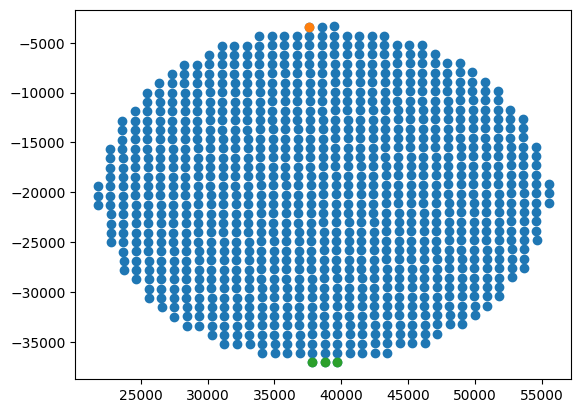

In [67]:
plt.scatter(test_phenotype_metadata.x_pos,test_phenotype_metadata.y_pos)
plt.scatter(test_phenotype_metadata.x_pos.iloc[-1],test_phenotype_metadata.y_pos.iloc[-1])
plt.scatter(test_phenotype_metadata.x_pos.iloc[0:3],test_phenotype_metadata.y_pos.iloc[0:3])

In [85]:
combos.tile

0          0
1          1
2          2
3          3
4          4
        ... 
3046    1012
3047    1013
3048    1014
3049    1015
3050    1016
Name: tile, Length: 3051, dtype: int64

In [94]:
combos = pd.read_csv('/Users/daeheehwang/Documents/python_analysis/brieflow-analysis/analysis/config/phenotype_combo.tsv',
                     sep='\t')
combos_2 = combos[~combos.tile.isin([1014, 1015, 1016])]

In [96]:
combos_2.to_csv('/Users/daeheehwang/Documents/python_analysis/brieflow-analysis/analysis/config/phenotype_combo.tsv',
                     sep='\t',index=False)

In [91]:
combos_2

,plate,round,well,channel,tile
0,1,1,A1,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",0
1,1,1,A1,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",1
2,1,1,A1,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",2
3,1,1,A1,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",3
4,1,1,A1,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",4
...,...,...,...,...,...
3043,1,1,A3,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",1009
3044,1,1,A3,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",1010
3045,1,1,A3,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",1011
3046,1,1,A3,"PacBlue_penta_20X,mNeonGreen_penta_20X,AF555_p...",1012


In [62]:
x_offset = test_phenotype_metadata.x_pos.iloc[-1] - test_phenotype_metadata_2.x_pos.iloc[-1]
y_offset = test_phenotype_metadata.y_pos.iloc[-1] - test_phenotype_metadata_2.y_pos.iloc[-1]

print(x_offset,y_offset)

78398.6 470.6999999999998


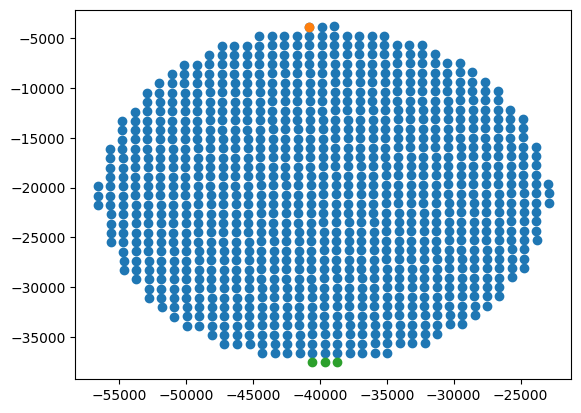

In [71]:
plt.scatter(test_phenotype_metadata_2.x_pos,test_phenotype_metadata_2.y_pos)
plt.scatter(test_phenotype_metadata_2.x_pos.tail(1),test_phenotype_metadata_2.y_pos.tail(1))
plt.scatter(test_phenotype_metadata.x_pos.iloc[0:3]-x_offset,test_phenotype_metadata.y_pos.iloc[0:3] - y_offset)

In [42]:
test_phenotype_metadata_2.x_pos.tail(1)

1013   -40807.3
Name: x_pos, dtype: float64

## <font color='red'>SET PARAMETERS</font>

### Image conversion

- `SBS_CHANNEL_ORDER`/`PHENOTYPE_CHANNEL_ORDER`: Manually set channel order _if ND2 images are acquired as single channels, or there are multiple files for each tile (e.g. multiple rounds of phenotype images). Should be `None` if multichannel image files are acquired. The extracted channel names must match the values that will be displayed in the samples DataFrame channel column (e.g., `["DAPI", "GFP", "CY3", "CY5", "AF750"]`).
- `PHENOTYPE_ROUND_ORDER`: List of round numbers specifying the order in which to process phenotype image rounds. Should be `None` if there is only one round of phenotyping. For multiple rounds, specify the round numbers in the desired order (e.g., `[1, 2, 3]`). The round numbers must match the values in the samples DataFrame round column.

**Note** For single-channel files, each file must contain a channel identifier that your regex can extract. For multichannel files, set the channel patterns to `None`. Metadata extraction is only performed on the first channel dimension for each tile. Please ensure the Dapi channel is displayed first!

- `SBS_CHANNEL_ORDER_FLIP`/`PHENOTYPE_CHANNEL_ORDER_FLIP`: Whether or not to flip channel order when converting ND2->tiff. Should be `False` if channels are in a standard order (with Dapi first), or `True` if channels are reversed. This will only occur for multichannel ND2 files, for each individual ND2 file. Setting the channel order for single channel files is done by setting `SBS_CHANNEL_ORDER`/`PHENOTYPE_CHANNEL_ORDER` previously.

**Note** Channel order can be checked with the test conversions below. Please ensure the Dapi channel is displayed first!

In [12]:
SBS_CHANNEL_ORDER = ["405_nm_-_Penta", "561_nm_-_G", "561_nm_-_T", "638_nm_-_A", "638_nm_-_C"]
PHENOTYPE_CHANNEL_ORDER = None
#PHENOTYPE_CHANNEL_ORDER = ["PacBlue_penta_20X","mNeonGreen_penta_20X","AF555_penta_20X","AF647_penta_20X","AF750_penta_20X"]
PHENOTYPE_ROUND_ORDER = None
SBS_CHANNEL_ORDER_FLIP = False
PHENOTYPE_CHANNEL_ORDER_FLIP = False

## Test Image Conversion

### Test SBS conversion

Testing SBS image conversion...
Z-aware stacking: 5 channels × 1 z-planes = 5 files
Processing TIFF file 1/5: /Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0_Fluorescence_405_nm_-_Penta.tiff
TIFF array shape: (1, 4168, 4168)
Processing TIFF file 2/5: /Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0_Fluorescence_561_nm_-_G.tiff
TIFF array shape: (1, 4168, 4168)
Processing TIFF file 3/5: /Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0_Fluorescence_561_nm_-_T.tiff
TIFF array shape: (1, 4168, 4168)
Processing TIFF file 4/5: /Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0_Fluorescence_638_nm_-_A.tiff
TIFF array shape: (1, 4168, 4168)
Processing TIFF file 5/5: /Volumes/Elements/sbs/plate_1/cycle_1/0/A1_0_0_Fluorescence_638_nm_-_C.tiff
TIFF array shape: (1, 4168, 4168)
Concatenated 5 files along channel axis: (5, 4168, 4168)
SBS converted image shape: (5, 4168, 4168)


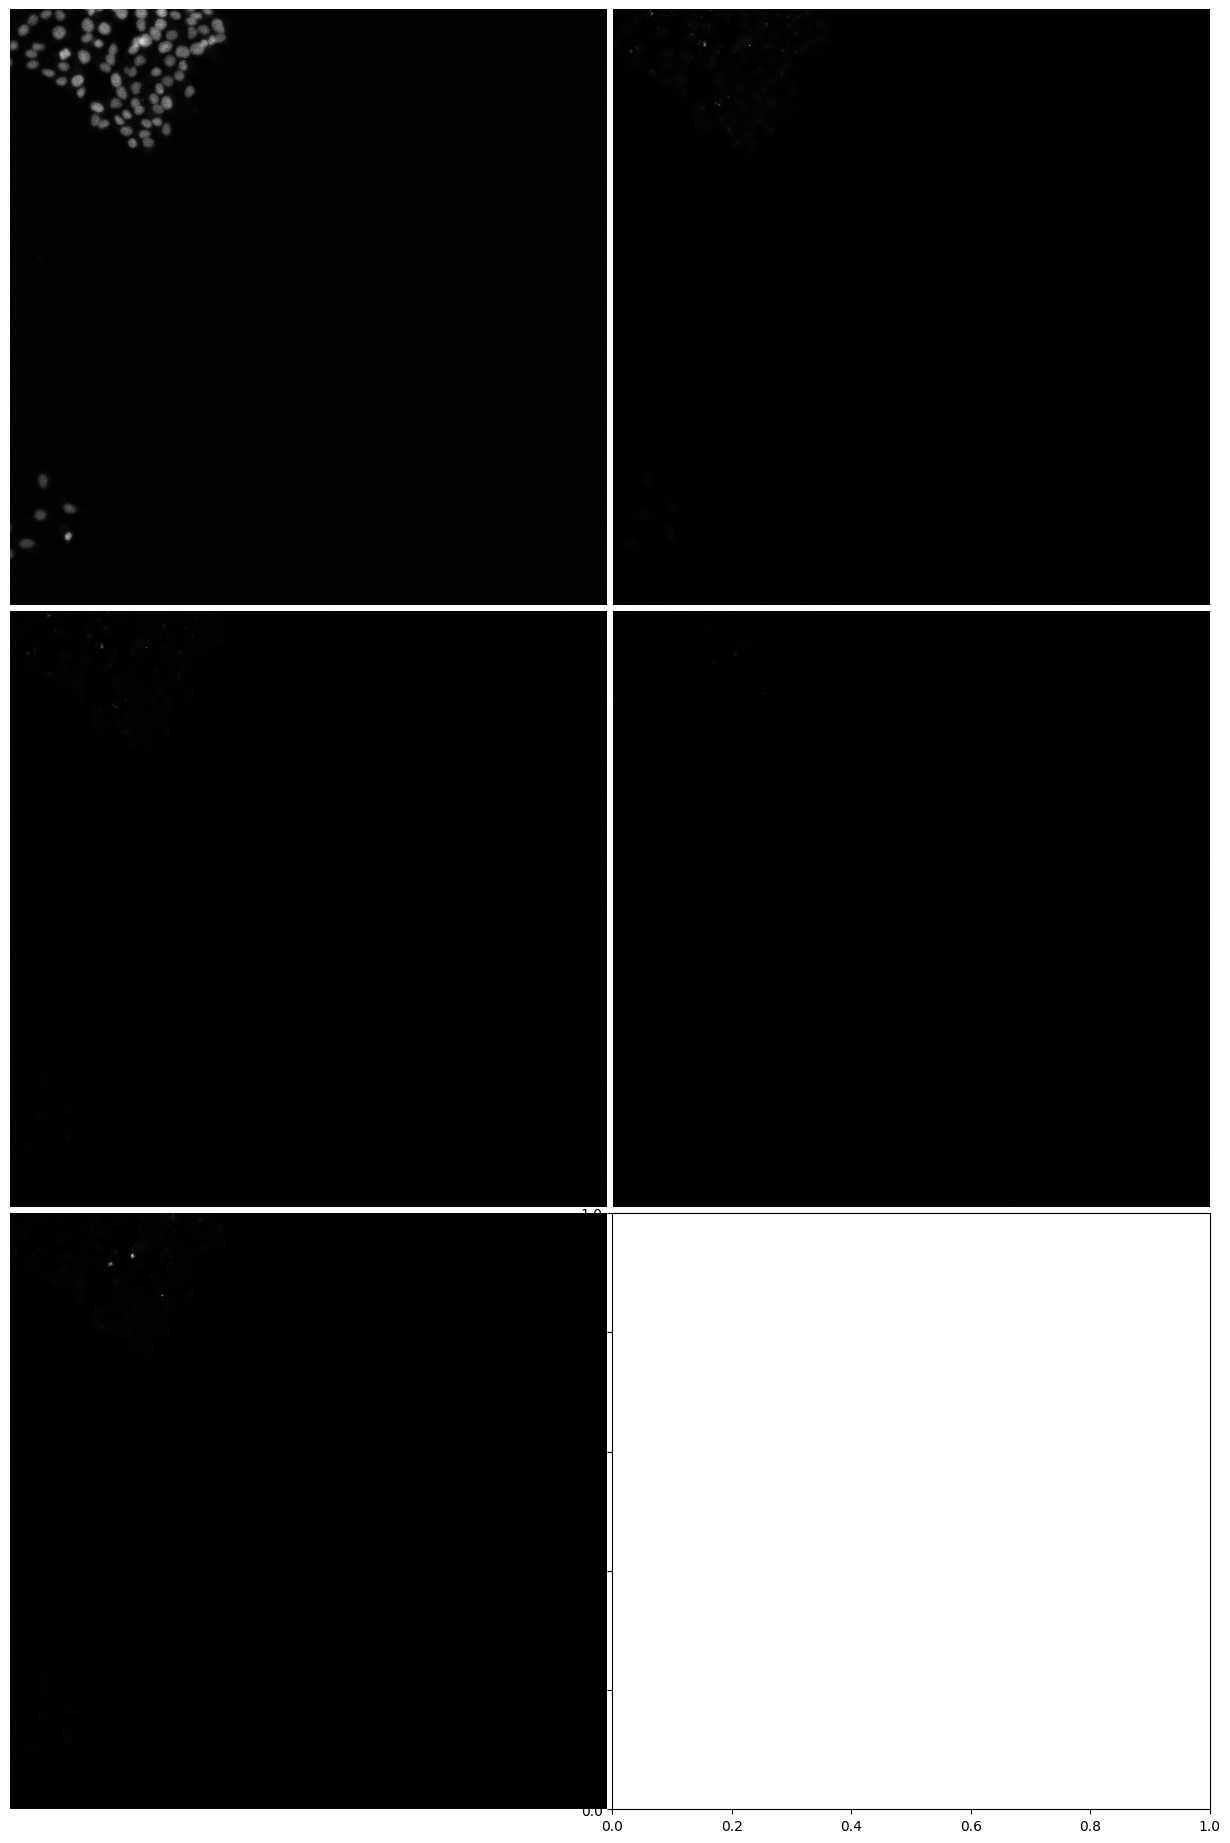

In [22]:
if len(sbs_samples) > 0:
    print("Testing SBS image conversion...")
    
    # Get sample files based on data organization
    if SBS_DATA_ORGANIZATION in {"tile", "channel"}:
        sbs_sample_files = get_sample_fps(
            sbs_samples,
            plate=sbs_samples["plate"].iloc[0],
            well=sbs_samples["well"].iloc[0],
            tile=sbs_samples["tile"].iloc[0] if "tile" in sbs_samples.columns else 0,
            cycle=sbs_samples["cycle"].iloc[0] if "cycle" in sbs_samples.columns else None,
            channel_order=SBS_CHANNEL_ORDER,
        )
    else:  # well organization
        sbs_sample_files = get_sample_fps(
            sbs_samples,
            plate=sbs_samples["plate"].iloc[0],
            well=sbs_samples["well"].iloc[0],
            cycle=sbs_samples["cycle"].iloc[0] if "cycle" in sbs_samples.columns else None,
            channel_order=SBS_CHANNEL_ORDER,
        )
        
    # Convert using unified function
    sbs_image = convert_to_array(
        sbs_sample_files,
        data_format=SBS_DATA_FORMAT,
        data_organization=SBS_DATA_ORGANIZATION,
        position=0 if SBS_DATA_ORGANIZATION == "well" else None,
        channel_order_flip=SBS_CHANNEL_ORDER_FLIP,
        n_z_planes=SBS_N_Z_PLANES,
        verbose=True
    )
    
    print(f"SBS converted image shape: {sbs_image.shape}")
    
    # Display images
    sbs_microimages = [Microimage(image) for image in sbs_image]
    sbs_panel = create_micropanel(sbs_microimages, add_channel_label=False)
    plt.title("SBS Test Conversion")
    plt.show()

### Test phenotype conversion

Testing phenotype image conversion...

Processing file: /Volumes/Elements/pheno/plate_1/round_1/WellA1_ChannelPacBlue_penta_20X,mNeonGreen_penta_20X,AF555_penta_20X,AF647_penta_20X,AF750_penta_20X_Seq0000.nd2
File dimensions: {'P': 1017, 'C': 5, 'Y': 3200, 'X': 3200}
Frame shape after Z processing: (5, 3200, 3200)
Final dimensions (CYX): (5, 3200, 3200)
Array size in bytes: 102400000
Phenotype converted image shape: (5, 3200, 3200)


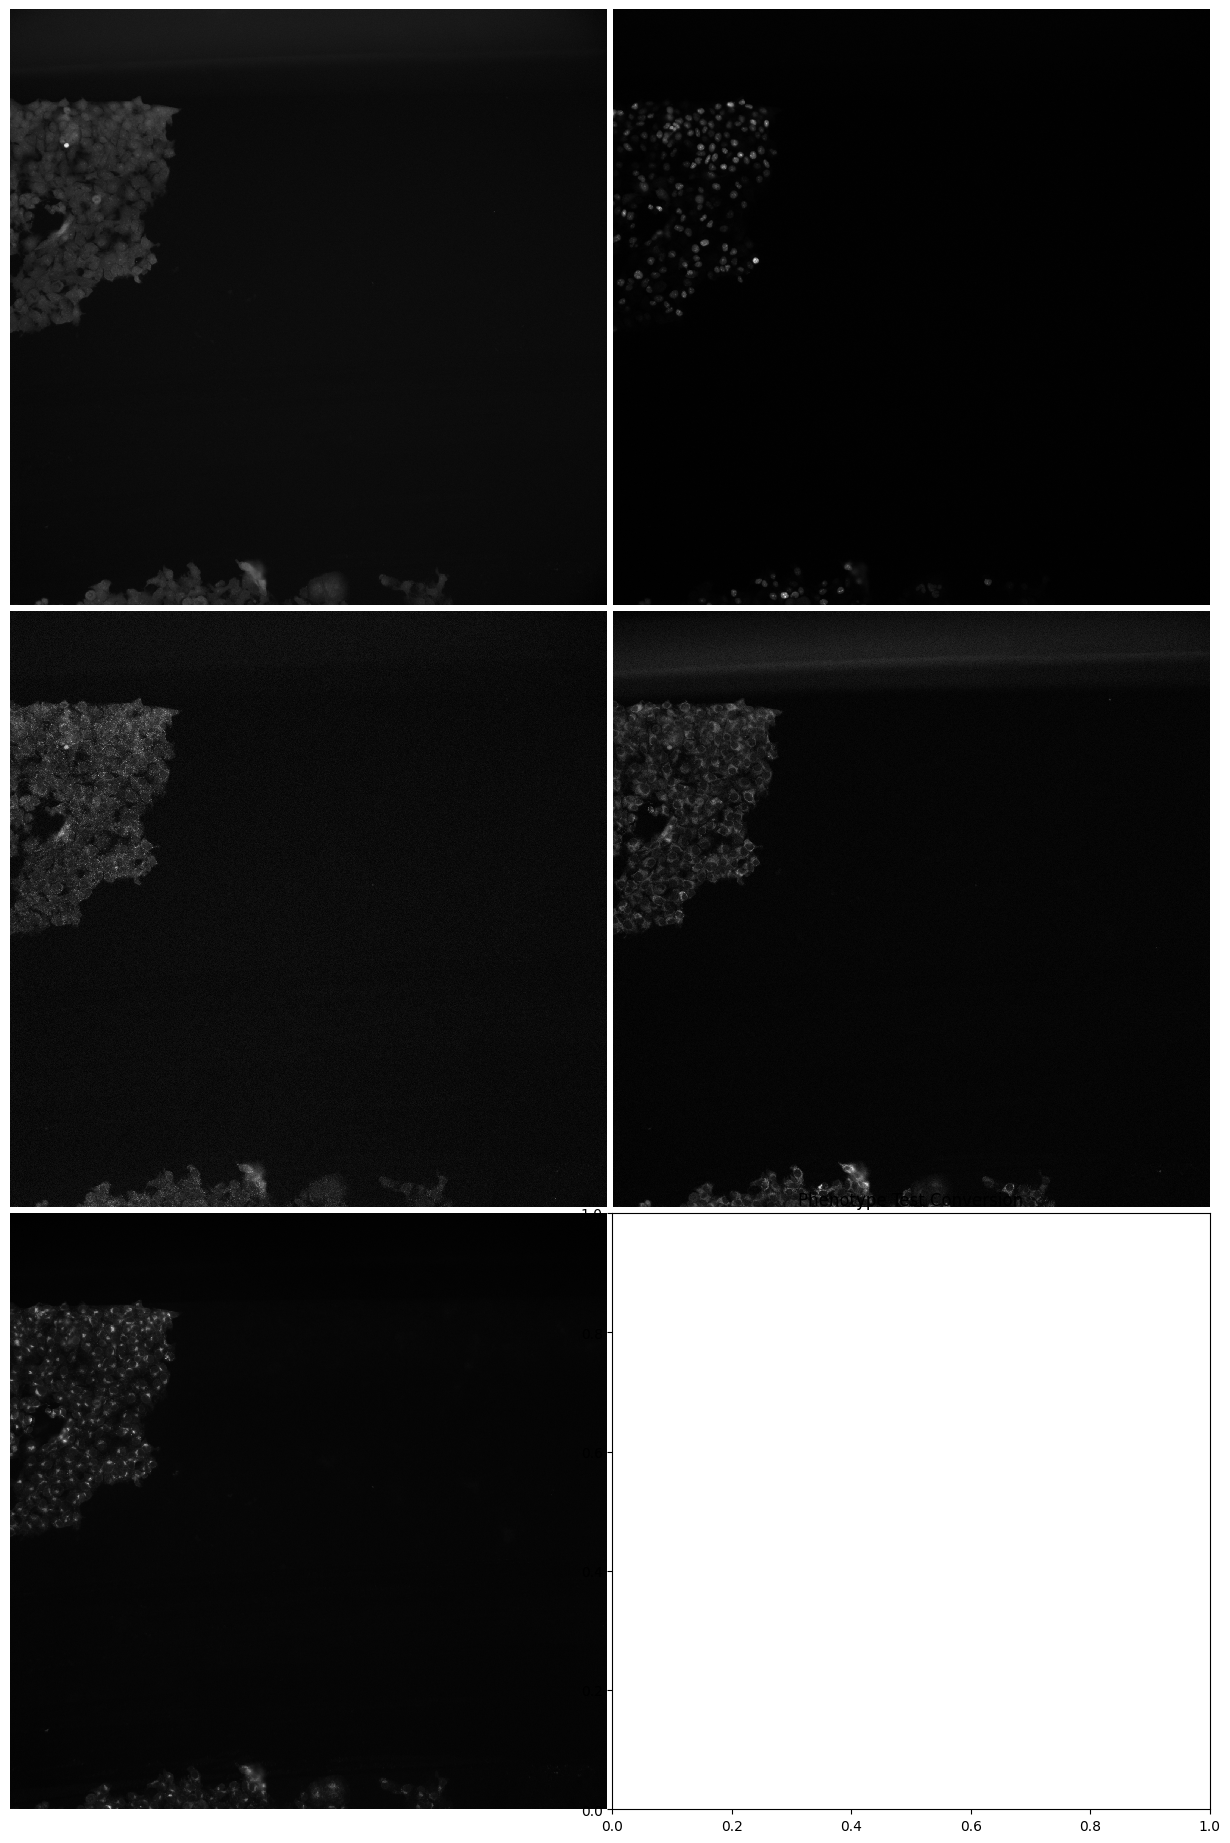

In [60]:
if len(phenotype_samples) > 0:
    print("Testing phenotype image conversion...")
    
    # Get sample files based on data organization
    if PHENOTYPE_DATA_ORGANIZATION == "tile":
        phenotype_sample_files = get_sample_fps(
            phenotype_samples,
            plate=phenotype_samples["plate"].iloc[0],
            well=phenotype_samples["well"].iloc[0],
            tile=phenotype_samples["tile"].iloc[0] if "tile" in phenotype_samples.columns else 0,
            round_order=PHENOTYPE_ROUND_ORDER,
            channel_order=PHENOTYPE_CHANNEL_ORDER,
        )
    else:  # well organization
        phenotype_sample_files = get_sample_fps(
            phenotype_samples,
            plate=phenotype_samples["plate"].iloc[0],
            well=phenotype_samples["well"].iloc[0],
            round_order=PHENOTYPE_ROUND_ORDER,
            channel_order=PHENOTYPE_CHANNEL_ORDER,
        )
      
    # Convert using unified function
    phenotype_image = convert_to_array(
        phenotype_sample_files,
        data_format=PHENOTYPE_DATA_FORMAT,
        data_organization=PHENOTYPE_DATA_ORGANIZATION,
        position=0 if PHENOTYPE_DATA_ORGANIZATION == "well" else None,
        channel_order_flip=PHENOTYPE_CHANNEL_ORDER_FLIP,
        n_z_planes=PHENOTYPE_N_Z_PLANES,
        verbose=True
    )
    
    print(f"Phenotype converted image shape: {phenotype_image.shape}")
    
    # Display images
    phenotype_microimages = [Microimage(image) for image in phenotype_image]
    phenotype_panel = create_micropanel(phenotype_microimages, add_channel_label=False)
    plt.title("Phenotype Test Conversion")
    plt.show()

## <font color='red'>SET PARAMETERS</font>

### Calculate illumination correction field

- `SAMPLE_FRACTION`: Controls what percentage of images to use when calculating the illumination correction field (0.0-1.0). Using a smaller fraction (e.g., 0.2 = 20%) speeds up processing by randomly sampling only a subset of your images. Default is 1.0 (use all images). For reliable results, ensure your sample contains enough images to accurately represent illumination variation.

In [24]:
SAMPLE_FRACTION = 0.2

In [27]:
SBS_DATA_ORGANIZATION

'tile'

## Create config file with params

In [25]:
# Create empty config variable
config = {}

# Add all section
config["all"] = {
    "root_fp": ROOT_FP,
}

# Add preprocess section
config["preprocess"] = {
    # File paths
    "sbs_samples_fp": SBS_SAMPLES_DF_FP,
    "sbs_combo_fp": SBS_COMBO_DF_FP,
    "phenotype_samples_fp": PHENOTYPE_SAMPLES_DF_FP,
    "phenotype_combo_fp": PHENOTYPE_COMBO_DF_FP,
    
    # SBS configuration
    "sbs_data_format": SBS_DATA_FORMAT,
    "sbs_data_organization": SBS_DATA_ORGANIZATION,
    "sbs_channel_order": SBS_CHANNEL_ORDER,
    "sbs_channel_order_flip": SBS_CHANNEL_ORDER_FLIP,
    "sbs_n_z_planes": SBS_N_Z_PLANES,
    "sbs_metadata_samples_df_fp": SBS_METADATA_SAMPLES_DF_FP,
    
    # Phenotype configuration
    "phenotype_data_format": PHENOTYPE_DATA_FORMAT,
    "phenotype_data_organization": PHENOTYPE_DATA_ORGANIZATION,
    "phenotype_channel_order": PHENOTYPE_CHANNEL_ORDER,
    "phenotype_channel_order_flip": PHENOTYPE_CHANNEL_ORDER_FLIP,
    "phenotype_round_order": PHENOTYPE_ROUND_ORDER,
    "phenotype_n_z_planes": PHENOTYPE_N_Z_PLANES,
    "phenotype_metadata_samples_df_fp": PHENOTYPE_METADATA_SAMPLES_DF_FP,

    # Processing parameters
    "sample_fraction": SAMPLE_FRACTION,
}

# Convert tuples to lists before dumping
safe_config = convert_tuples_to_lists(config)

# Write the updated configuration back with markdown-style comments
with open(CONFIG_FILE_PATH, "w") as config_file:
    # Write the introductory markdown-style comments
    config_file.write(CONFIG_FILE_HEADER)

    # Dump the updated YAML structure, keeping markdown comments for sections
    yaml.dump(safe_config, config_file, default_flow_style=False, sort_keys=False)